### Online scalable Gaussian processes with conformal prediction for guaranteed coverage; J. Xu, Q. Lu, G. B. Giannakis
(ICASSP 2025; arXiv:2410.05444)

**Abstract** - The Gaussian process (GP) is a Bayesian nonparametric paradigm that is widely adopted for uncertainty quantification (UQ) in a number of safety-critical applications, including robotics, healthcare, as well as surveillance. The consistency of the resulting uncertainty values however, hinges on the premise that the learning function conforms to the properties specified by the GP model, such as smoothness, periodicity and more, which may not be satisfied in practice, especially with data arriving on the fly. To combat against such model misspecification, we propose to wed the GP with the prevailing conformal prediction (CP), a distribution-free post-processing framework that produces prediction sets with a provably valid coverage under the sole assumption of data exchangeability. However, this assumption is usually violated in the online setting, where a prediction set is sought before revealing the true label. To ensure long-term coverage guarantee, we will adpatively set the key threshold parameter based on the feedback whether the true label falls inside the prediction set. Numerical results demonstrate the merits of the online GP-CP approach relative to existing alternatives in the long-term coverage performance.

## 0. Module imports

In [1]:
import numpy as np
from scipy.stats import cauchy, gamma, chi2
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

import matplotlib.pyplot as plt

## 1. Preliminaries — Gaussian-process posterior (§II.A)

The GP places a prior $f\sim\mathcal{GP}(0,\kappa(x,x'))$. For a test input $x$, the joint of past labels and the new output is Gaussian (eq. 1):

$$\begin{bmatrix} \mathbf{y}_t \\ y_{t+1}\end{bmatrix}\sim\mathcal N\left(\mathbf 0,\ \begin{bmatrix} \mathbf K_t & \mathbf k_t(x)\\ \mathbf k_t^\top(x) & \kappa(x,x)+\sigma_n^2\end{bmatrix}\right).$$

Conditioning on $\mathcal D_t=\{\mathbf X_t,\mathbf y_t\}$ gives the predictive pdf (eq. 2) and its mean/variance (eq. 3):

$$p(y\mid\mathcal D_t,x)=\mathcal N\!\big(y;\ \hat y_t(x),\ \sigma_t^2(x)\big)$$
$$\hat y_t(x)=\mathbf k_t^\top(x)\,(\mathbf K_t+\sigma_n^2\mathbf I_t)^{-1}\mathbf y_t$$
$$\sigma_t^2(x)=\kappa(x,x)-\mathbf k_t^\top(x)(\mathbf K_t+\sigma_n^2\mathbf I_t)^{-1}\mathbf k_t(x)+\sigma_n^2.$$

For $\beta=95\%$ the **Bayes credible set** is $K_t^\beta(x)=[\hat y_t(x)-2\sigma_t(x),\ \hat y_t(x)+2\sigma_t(x)]$.

The catch the paper flags: this is only well-calibrated when the data match the GP assumptions, and inverting the $t\times t$ matrix $\mathbf K_t$ costs $O(t^3)$, "which will become prohibitively high as $t$ grows." Both problems motivate the rest of the paper. **No code implements (1)–(3) directly** — the exact kernel matrix is never formed; §III replaces it with the random-feature weight space (below), which is what makes the update $O((2D)^2)$ per step.

## 2. Preliminaries — conformal prediction (§II.B)

Given a negatively-oriented conformity score $s_t(x,y)$, the conformal set (eq. 4) is

$$C_t(x)=\{y\in\mathcal Y:\ s_t(x,y)\le q_t\},$$

where $q_t$ is "an estimated $1-\alpha$ quantile for the distribution of the score." In **standard CP**, $q_t$ is the $\lceil(1-\alpha)(t+1)\rceil$-th smallest of the past scores $\{s(x_\tau,y_\tau)\}_{\tau=1}^t$; under exchangeability this yields $P(y\in C_t(x))\ge 1-\alpha$. The paper then notes exchangeability "is often violated in practise, especially in the online setting," which is what the adaptive threshold in §III.B fixes.

The score used throughout is the **Gaussian negative log-likelihood** $s_t(y)=\tfrac12\log(2\pi\sigma_t^2)+\tfrac{(y-\hat y_t)^2}{2\sigma_t^2}$; inverting $s_t(y)\le q$ gives the closed interval $\hat y_t\pm\sqrt{2\sigma_t^2\,(q-\tfrac12\log 2\pi\sigma_t^2)}$.

`standard_cp` implements eq. (4) with this score: it keeps the empirical $1-\alpha$ quantile of past scores (`np.quantile(past, 1-alpha)`) and inverts the NLL to a band (`rad`, `h`).

In [2]:
# comes from https://github.com/yuhenglai/OLCP/blob/main/cp_methods.py
def run_plain_cp(calib_scores, alpha, plus_one=True):
    calib_scores = np.asarray(calib_scores, float).ravel()
    r = len(calib_scores)
    if r == 0:
        return np.inf
    if plus_one:
        k = int(np.ceil((1 - alpha) * (r + 1)))
    else:
        k = int(np.ceil((1 - alpha) * r))
    k = min(max(k, 1), r)
    return float(np.sort(calib_scores)[k - 1])


# idk where this is from
def standard_cp(y, mu, var, alpha=0.1):
    T = len(y)
    var = np.maximum(np.asarray(var, float), 1e-12)
    nll_min = 0.5 * np.log(2 * np.pi * var)              # min score, at y = mu
    score = nll_min + (y - mu) ** 2 / (2 * var)          # observed score s_t(Y_t)

    lo = np.full(T, np.nan)
    hi = np.full(T, np.nan)
    covered = np.zeros(T, bool)
    size = np.zeros(T)
    past = []

    for t in range(T):
        q = np.quantile(past, 1-alpha, method="higher") if past else score[t]
        rad = 2 * var[t] * (q - nll_min[t])
        if rad >= 0:
            h = np.sqrt(rad)
            lo[t], hi[t] = mu[t]-h, mu[t]+h
            size[t] = 2 * h
        covered[t] = score[t] <= q
        past.append(score[t])
    return dict(lo=lo, hi=hi, covered=covered, size=size)

In [3]:
def standard_cp(y, mu, var, alpha=0.1):
    T = len(y)
    var = np.maximum(np.asarray(var, float), 1e-12)
    nll_min = 0.5 * np.log(2 * np.pi * var)              # min score, at y = mu
    score = nll_min + (y - mu) ** 2 / (2 * var)          # observed score s_t(Y_t)

    lo = np.full(T, np.nan)
    hi = np.full(T, np.nan)
    covered = np.zeros(T, bool)
    size = np.zeros(T)
    past = []

    for t in range(T):
        q = np.quantile(past, 1-alpha, method="higher") if past else score[t]
        rad = 2 * var[t] * (q - nll_min[t])
        if rad >= 0:
            h = np.sqrt(rad)
            lo[t], hi[t] = mu[t]-h, mu[t]+h
            size[t] = 2 * h
        covered[t] = score[t] <= q
        past.append(score[t])
    return dict(lo=lo, hi=hi, covered=covered, size=size)

## 3. Scalable GP via random features (§III.A) — eqs (5)–(7)

For a standardised shift-invariant kernel $\bar\kappa$, Bochner's theorem writes it as the Fourier transform of a power spectral density $\pi_{\bar\kappa}$ (eq. 5):

$$\bar\kappa(x,x')=\int \pi_{\bar\kappa}(v)\,e^{jv^\top(x-x')}\,dv=\mathbb E_{\pi_{\bar\kappa}}\!\big[e^{jv^\top(x-x')}\big],$$

where, "after normalizing so that $\pi_{\bar\kappa}(v)$ integrates to 1," the PSD is treated as a pdf. Drawing $D$ i.i.d. frequencies $\{v_i\}$ from it and stacking sines/cosines gives the real random-feature map (eq. 6):

$$\phi_v(x)=\tfrac{1}{\sqrt D}\big[\sin(v_1^\top x),\cos(v_1^\top x),\dots,\sin(v_D^\top x),\cos(v_D^\top x)\big]^\top,$$

so that $\bar\kappa(x,x')\approx\phi_v^\top(x)\phi_v(x')$. The parametric approximant (eq. 7) is then a plain linear model with a Gaussian prior on the weights:

$$\check f(x)=\phi_v^\top(x)\,\theta,\qquad \theta\sim\mathcal N(\mathbf 0_{2D},\ \sigma_\theta^2\mathbf I_{2D}),$$

which yields the GP prior with $\kappa=\sigma_\theta^2\bar\kappa$.

`rff_features` builds eq. (6) (`V` is the $d\times D$ matrix of sampled frequencies; output is $2D$-dimensional).

In [4]:
def rff_features(X, V):
    """X:(N, d), V:(d, D)  ->  Z:(N, 2D)."""
    D = V.shape[1]
    VX = X @ V
    return np.sqrt(1.0 / D) * np.concatenate([np.sin(VX), np.cos(VX)], axis=1)

The four samplers draw the frequencies $v\sim\pi_{\bar\kappa}$ for each kernel's spectral density — eq. (5) specialised: Gaussian for the RBF, Cauchy for the Laplacian, Student-$t$ (a Gaussian scale-mixture) for Matérn-$\nu$, and a Gamma scale-mixture of Gaussians for the rational quadratic.

In [5]:
def sample_rbf(d, D, length_scale, rng):
    # RBF: omega ~ N(0, 1/l^2)
    return rng.normal(0.0, 1.0 / length_scale, size=(d, D))


def sample_laplacian(d, D, length_scale, rng):
    # exp(-|r|/l): omega ~ Cauchy(0, scale = 1/l)
    return cauchy.rvs(loc=0.0, scale=1.0 / length_scale,
                      size=(d, D), random_state=rng)


def sample_matern(d, D, length_scale, nu, rng):
    # Matern-nu: omega ~ Student-t with dof = 2*nu, scale = 1/l.
    #   omega = z / sqrt(g),  z ~ N(0, 1/l^2),  g ~ Gamma(nu, scale=1/nu)
    g = gamma.rvs(a=nu, scale=1.0 / nu, size=D, random_state=rng)
    z = rng.normal(0.0, 1.0 / length_scale, size=(d, D))
    return z / np.sqrt(g)[None, :]


def sample_rq(d, D, length_scale, alpha, rng):
    # Rational quadratic = scale-mixture of RBFs:
    #   omega = z * sqrt(u),  z ~ N(0, 1),  u ~ Gamma(alpha, scale=1/(alpha*l^2))
    u = gamma.rvs(a=alpha, scale=1.0 / (alpha * length_scale ** 2),
                  size=D, random_state=rng)
    z = rng.normal(0.0, 1.0, size=(d, D))
    return z * np.sqrt(u)[None, :]

## 4. Online predictive pdf and the recursive update (§III.A) — eqs (8), (10)–(11)

With the linear model, prediction at slot $t+1$ (eq. 8) is

$$p(y_{t+1}\mid\mathcal D_t,x_{t+1})=\mathcal N\!\big(y_{t+1};\ \hat y_{t+1|t},\ \sigma_{t+1|t}^2\big),$$
$$\hat y_{t+1|t}=\phi_v^\top(x_{t+1})\hat\theta_t,\qquad \sigma_{t+1|t}^2=\phi_v^\top(x_{t+1})\Sigma_t\phi_v(x_{t+1})+\sigma_n^2.$$

After $y_{t+1}$ arrives, the weight posterior is updated by Bayes' rule (eq. 10) to $\mathcal N(\theta;\hat\theta_{t+1},\Sigma_{t+1})$ with the recursions (eq. 11):

$$\hat\theta_{t+1}=\hat\theta_t+\sigma_{t+1|t}^{-2}\,\Sigma_t\phi_v(x_{t+1})\,(y_{t+1}-\hat y_{t+1|t}),$$
$$\Sigma_{t+1}=\Sigma_t-\sigma_{t+1|t}^{-2}\,\Sigma_t\phi_v(x_{t+1})\phi_v^\top(x_{t+1})\Sigma_t.$$

The per-slot cost is only $O((2D)^2)$ and the scheme is "memoryless that requires no storage of past data." `run_online_gp_recursive` is a line-for-line implementation: prior $\Sigma_0=\sigma_\theta^2\mathbf I$ (`sigma_f**2`), predictive `s2` = eq. (8), then the two updates in eq. (11) (`gain` carries $\sigma_{t+1|t}^{-2}\Sigma\phi$).

In [6]:
def run_online_gp_recursive(X_all, y_all, V, sigma_n, sigma_f, n_init=100):
    # Memoryless Bayesian update of the RFF weight posterior (paper eqs. 10-11).
    M = 2 * V.shape[1]
    theta = np.zeros(M)
    Sigma = (sigma_f ** 2) * np.eye(M) # prior  theta ~ N(0, sigma_f^2 I)
    Z = rff_features(X_all, V)
    sn2 = sigma_n ** 2
    preds, truths, varis = [], [], []
    for t in range(len(X_all)):
        phi = Z[t]
        mu = phi @ theta
        Sphi = Sigma @ phi
        s2 = float(phi @ Sphi + sn2) # predictive variance sigma^2_{t+1|t}
        if t >= n_init:
            preds.append(mu)
            truths.append(y_all[t])
            varis.append(s2)
        gain = Sphi / s2 # recursive update
        theta = theta + gain * (y_all[t] - mu)
        Sigma = Sigma - np.outer(Sphi, Sphi) / s2
        Sigma = 0.5 * (Sigma + Sigma.T) # symmetric
    return np.array(preds), np.array(truths), np.array(varis)

`gp_predict` is the equivalent **batch** weight-space solve — the same posterior computed in one shot from all data seen so far, $A=Z^\top Z+(\sigma_n^2/\sigma_\theta^2)\mathbf I$, $\mu_*=Z_*A^{-1}Z^\top y$, $\mathrm{var}_*=\sigma_n^2\,\mathrm{diag}(Z_*A^{-1}Z_*^\top)+\sigma_n^2$. It is used by the mini-batch driver `run_online_gp`; it gives the same predictions as the recursion but stores past data, so it is the non-memoryless variant.

In [7]:
def gp_predict(Z_train, y_train, Z_test, sigma_n, sigma_f):
    M = Z_train.shape[1]
    A = Z_train.T @ Z_train + (sigma_n ** 2 / sigma_f ** 2) * np.eye(M)
    w = np.linalg.solve(A, Z_train.T @ y_train)          # posterior mean weights
    mu = Z_test @ w
    AinvZt = np.linalg.solve(A, Z_test.T)                # (M, N_test)
    var = sigma_n ** 2 * np.einsum('ij,ji->i', Z_test, AinvZt) + sigma_n ** 2
    return mu, var


def run_online_gp(X_all, y_all, V, sigma_n, sigma_f, n_init=50, batch=50):
    X_tr, y_tr = X_all[:n_init].copy(), y_all[:n_init].copy()
    Z_tr = rff_features(X_tr, V)

    preds, truths, varis = [], [], []
    for i in range(n_init, len(X_all), batch):
        X_new, y_new = X_all[i:i + batch], y_all[i:i + batch]
        Z_new = rff_features(X_new, V)

        mu, var = gp_predict(Z_tr, y_tr, Z_new, sigma_n, sigma_f)
        preds.extend(mu)
        truths.extend(y_new)
        varis.extend(var)

        # absorb the new data into the training set
        X_tr = np.vstack([X_tr, X_new])
        y_tr = np.append(y_tr, y_new)
        Z_tr = np.vstack([Z_tr, Z_new])

    return np.array(preds), np.array(truths), np.array(varis)

## 5. Bayes credible set for the online GP (§III.A) — eq. (9)

Using the predictive of eq. (8), the Bayes $\beta$-credible set is (eq. 9)

$$K_t^\beta(x_{t+1})=[\hat y_{t+1|t}-c_\beta\,\sigma_{t+1|t},\ \hat y_{t+1|t}+c_\beta\,\sigma_{t+1|t}],$$

with $c_\beta$ **constant over time**. The paper's point is that under model mis-specification this set "might have poor coverage." `bayes_credible` uses $c_\beta=\Phi^{-1}(1-\alpha/2)$ (=1.645 at $\alpha=0.1$, i.e. $\beta=1-\alpha$).

In [8]:
def bayes_credible(y, mu, var, alpha=0.1):
    c = norm.ppf(1 - alpha / 2)                       # fixed multiplier (1.645 @ alpha=0.1)
    sd = np.sqrt(np.maximum(var, 1e-12))
    return dict(lo=mu - c*sd, hi=mu + c*sd,
                covered=np.abs(y - mu) <= c*sd, size=2*c*sd)

## 6. OS-GP with CP — conformalised set and threshold update (§III.B) — eqs (12)–(14)

The score is "chosen to be the negative predictive log-likelihood," $s_t(x,y)=-\log p(y\mid\mathcal D_t,x)$. The conformal Bayes set (eq. 12) is the interval obtained by inverting $s_t\le q_t$:

$$C_t(x_{t+1})=\{y:\ s_t(x_{t+1},y)\le q_t\}=\big[\hat y_{t+1|t}-c_{t+1|t}\,\sigma_{t+1|t},\ \hat y_{t+1|t}+c_{t+1|t}\,\sigma_{t+1|t}\big],$$
$$c_{t+1|t}=\sqrt{2q_t-\log\!\big(2\pi\sigma_{t+1|t}^2\big)}.$$

Unlike the constant $c_\beta$ in eq. (9), here $c_{t+1|t}$ "changes over time, adapting to new data samples." The threshold is updated from the coverage feedback (eq. 13), equivalently online sub-gradient descent on the pinball loss (eq. 14):

$$q_{t+1}=q_t+\eta_t\big(\mathbb I(y_{t+1}\notin C_t(x_{t+1}))-\alpha\big),$$
$$q_{t+1}=q_t-\eta_t\,\nabla\rho_{1-\alpha}\big(s_t(x_{t+1},y_{t+1})-q_t\big),\quad \rho_{1-\alpha}(u)=(1-\alpha)\max\{u,0\}+\alpha\max\{-u,0\}.$$

In `online_conformal` below: `rad`/`h` invert eq. (12) (`h`$=c_{t+1|t}\sigma_{t+1|t}$; the set is empty when `rad<0`); `covered[t]` is $s_t\le q$; and the last line `q = q + eta*(...)` is eq. (13). The learning-rate `eta` is set by the `step` argument (next section).

In [9]:
def online_conformal(y, mu, var, alpha=0.1, step="varying", c=1.0, eps=0.1,
                     W=15, r=100, q1=None):
    y = np.asarray(y, float)
    T = len(y)
    var = np.maximum(np.asarray(var, float), 1e-12)
    nll_min = 0.5 * np.log(2 * np.pi * var)
    score   = nll_min + (y - mu) ** 2 / (2 * var)

    if q1 is None:
        q1 = float(np.median(nll_min) + chi2.ppf(1.0 - alpha, df=1) / 2)
    q = q1

    lo = np.full(T, np.nan)
    hi = np.full(T, np.nan)
    size = np.zeros(T)
    covered = np.zeros(T, bool)
    q_path = np.empty(T)

    resets, win = [], []
    tau = 1
    prev_avg = None
    rises = 0
    a = 0.5 + eps

    for t in range(T):
        q_path[t] = q
        rad = 2 * var[t] * (q - nll_min[t])
        if rad >= 0.0:
            h = np.sqrt(rad)
            lo[t], hi[t] = mu[t] - h, mu[t] + h
            size[t] = 2 * h
        covered[t] = score[t] <= q

        if step == "varying":
            win.append(size[t])
            if len(win) > W:
                win.pop(0)
            if len(win) == W:                       # set-size change detector
                avg = np.mean(win)
                if (prev_avg is not None and avg > prev_avg):
                    rises +=1
                else:
                    rises = 0
                prev_avg = avg
                if rises >= r:
                    tau = 1
                    rises = 0
                    resets.append(t)
            eta = c * tau ** (-a)
            tau += 1
        elif step == "decaying":
            eta = c * (t + 1) ** (-a)
        else: # fixed constant eta
            eta = float(step)

        q = q + eta * ((0.0 if covered[t] else 1.0) - alpha)
    return dict(lo=lo, hi=hi, size=size, covered=covered, q_path=q_path, resets=resets)

## 7. Learning-rate schedules and change-point reset (§III.B)

The paper studies three regimes for $\eta_t$, all present in `online_conformal` via `step`:

- **Constant** $\eta_t=\eta$ (Gibbs & Candès): "can achieve guaranteed coverage asymptotically" but "will yield high variability in the instantaneous coverage." → `step=<float>` (the experiments use $\eta=0.05$).
- **Decaying** $\eta_t\propto t^{-a}$, $a\in(0,1)$: valid when the data are "stationary or [have] slow-varying dynamics." → `step="decaying"` with `eta = c*(t+1)**(-a)`, `a = 0.5+eps` (the experiments use $\eta_t=t^{-3/5}$, i.e. `eps=0.1`).
- **Varying** $\eta_t=\tau^{-a}$ with $\tau$ the slots since the last reset. On a sudden shift "the learning rate has to be reset to recover coverage." The detector uses the set size $|C_t|=2c_{t+1|t}\sigma_{t+1|t}$: average it over a window of $W$ slots, and "if the average prediction set size increases over $r$ consecutive steps, we will declare a distributional shift and then reset the learning rate." → `step="varying"`; the window/counter/`resets` block implements exactly this, with `W=15`, `r=100` as in the experiments.

The three branches sit in the `if step == ...` block above.

## 8. Long-run coverage theorem (§III.B) — eq. (15)

For any data sequence and any positive $\{\eta_t\}$, with the score bounded in $[0,B]$ and $q_0\in[0,B]$, the long-run coverage of OS-GP-CP obeys (eq. 15):

$$\left|\frac{1}{T}\sum_{t=0}^{T-1}\mathbb I\big(y_{t+1}\in C_t(x_{t+1})\big)-(1-\alpha)\right|\le \frac{C\,N_T}{T},$$

$$C=\frac{2\big(B+\max_{0\le t\le T-1}\eta_t\big)}{\min_{0\le t\le T-1}\eta_t},\qquad N_T=\sum_{\tau=1}^{T}\mathbb I(\eta_\tau>\eta_{\tau-1}).$$

$N_T$ counts how many times the learning rate is *increased* (i.e. reset). The takeaway: "as long as the step size does not decay too quickly, and the number of resets $N_T$ is sublinear in $T$, OS-GP-CP can achieve long-run coverage convergence." There is no code for the theorem itself; the `resets` list returned by `online_conformal` is exactly the $N_T$ events, and the varying schedule is designed to keep them sublinear.

## 9. Hyperparameters and setup (§IV)

The experiments fit the GP once on the first 100 points: "the kernel magnitude $\sigma_\theta^2$ and characteristic lengthscale $\sigma_l^2$ are optimized together with the noise variance $\sigma_n^2$ by maximizing the marginal likelihood using the first 100 data points," with $D=200$ spectral features and an RBF kernel. `fit_hyperparameters` does exactly this via scikit-learn's `ConstantKernel*RBF + WhiteKernel`, returning $(\ell,\ \sigma_\theta,\ \sigma_n)$.

In [10]:
def fit_hyperparameters(X, y, n0=100):
    k = (ConstantKernel(1.0,(1e-3,1e3))*RBF(1.0,(1e-2,1e2)) + WhiteKernel(0.1,(1e-6,1e1)))
    gpr = GaussianProcessRegressor(kernel=k, alpha=0.0, n_restarts_optimizer=2).fit(X[:n0], y[:n0])
    p = gpr.kernel_.get_params()
    return (float(p["k1__k2__length_scale"]),                 # length_scale
            float(np.sqrt(p["k1__k1__constant_value"])),      # sigma_f
            float(np.sqrt(max(p["k2__noise_level"], 1e-6))))  # sigma_n

# 10. Experiments

In [11]:
ALPHA = 0.1
D_FEAT = 200
RNG_SEED = 42

In [12]:
# ----- metrics & driver ----------------------------------------------
def long_run_coverage(covered):
    covered = np.asarray(covered, float)
    return np.cumsum(covered) / np.arange(1, len(covered) + 1)


def run_experiment(X, y, alpha=ALPHA, D=D_FEAT, n_init=100,
                   standardize=False, seed=RNG_SEED, varying_kwargs=None):
    """Fit hyper-params, run the online RFF-GP once, evaluate all four methods."""
    rng = np.random.RandomState(seed)
    X = np.asarray(X, float); y = np.asarray(y, float)
    if standardize:                       # causal z-scoring using the warm-up window
        mx, sx = X[:n_init].mean(0), X[:n_init].std(0) + 1e-12
        my, sy = y[:n_init].mean(),  y[:n_init].std()  + 1e-12
        X = (X - mx) / sx; y = (y - my) / sy
    d = X.shape[1]
    length_scale, sigma_f, sigma_n = fit_hyperparameters(X, y, n0=n_init)
    V = sample_rbf(d, D, length_scale, rng)               # paper uses the RBF kernel
    preds, truth, varis = run_online_gp(X, y, V, sigma_n, sigma_f,
                                        n_init=n_init)
    vk = varying_kwargs or {}
    methods = {
        "Bayes credible set":        bayes_credible(truth, preds, varis, alpha),
        "Standard CP":               standard_cp(truth, preds, varis, alpha),
        "OS-GP-CP (fixed eta=0.05)": online_conformal(truth, preds, varis,
                                                       alpha=alpha, step=0.05),   # fixed eta = 0.05
        "OS-GP-CP (varying eta_t)":  online_conformal(truth, preds, varis,
                                                       alpha=alpha, step="varying") ,
    }
    for m in methods.values():                            # ensure a 'size' field
        if "size" not in m:
            m["size"] = np.nan_to_num(m["hi"] - m["lo"], nan=0.0)
    return dict(preds=preds, truth=truth, varis=varis, methods=methods,
                hyper=(length_scale, sigma_f, sigma_n))


# ----- plotting & reporting ------------------------------------------
COLORS = {"Bayes credible set": "C2", "Standard CP": "C3",
          "OS-GP-CP (fixed eta=0.05)": "C1", "OS-GP-CP (varying eta_t)": "C0"}


def _rolling(arr, w=200):
    arr = np.asarray(arr, float)
    return arr if len(arr) < w else np.convolve(arr, np.ones(w) / w, mode="valid")


def plot_results(res, title, alpha=ALPHA, size_window=200, burn_in=100):
    methods = res["methods"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
    for name, m in methods.items():
        lrc = long_run_coverage(m["covered"])
        t = np.arange(len(lrc))
        ax[0].plot(t[burn_in:], lrc[burn_in:], color=COLORS[name], lw=1.5, label=name)
        ax[1].plot(_rolling(m["size"], size_window), color=COLORS[name], lw=1.5, label=name)
    ax[0].axhline(1 - alpha, color="k", ls=":", lw=1, label=f"target {1 - alpha:.2f}")
    for r in methods["OS-GP-CP (varying eta_t)"]["resets"]:
        for a_ in ax:
            a_.axvline(r, color="C0", ls="--", lw=0.7, alpha=0.5)
    ax[0].set(title="Long-run average coverage", xlabel="prediction slot t",
              ylabel="coverage"); ax[0].set_ylim(0.4, 1.02); ax[0].legend(fontsize=7)
    ax[1].set(title=f"Prediction-set size (rolling mean, w={size_window})",
              xlabel="prediction slot t", ylabel="size"); ax[1].legend(fontsize=7)
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def summarize(res, alpha=ALPHA):
    print(f"  fitted hyper-params:  lengthscale={res['hyper'][0]:.3f}  "
          f"sigma_f={res['hyper'][1]:.3f}  sigma_n={res['hyper'][2]:.3f}")
    print(f"  {'method':28s}{'final coverage':>16s}{'mean size':>12s}")
    for name, m in res["methods"].items():
        cov = long_run_coverage(m["covered"])[-1]
        print(f"  {name:28s}{cov:>16.3f}{np.mean(m['size']):>12.3f}")
    rs = res["methods"]["OS-GP-CP (varying eta_t)"]["resets"]
    print(f"  change-points detected (varying eta_t): {rs}")


# 10.1 Experiment 1

Synthetic i.i.d.:
  fitted hyper-params:  lengthscale=2.055  sigma_f=1.230  sigma_n=0.101
  method                        final coverage   mean size
  Bayes credible set                     0.906       0.334
  Standard CP                            0.901       0.329
  OS-GP-CP (fixed eta=0.05)              0.900       0.331
  OS-GP-CP (varying eta_t)               0.900       0.328
  change-points detected (varying eta_t): []


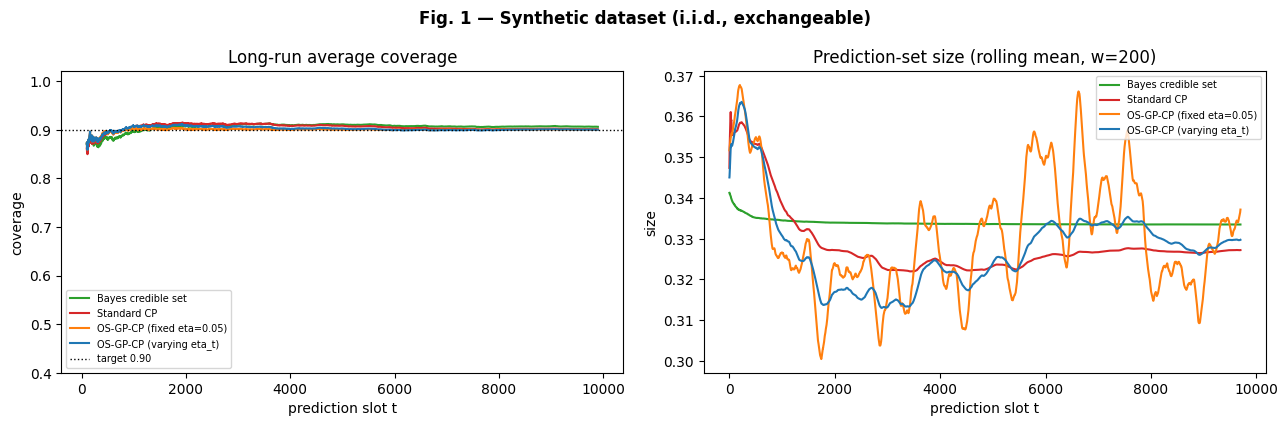

In [13]:
# --- dataset from data.ipynb (cell: "iid data") ---
np.random.seed(42)
X_iid = np.random.rand(10000, 1) * 10
y_iid = np.sin(X_iid[:, 0]) + np.random.randn(10000) * 0.1

res_iid = run_experiment(X_iid, y_iid)
print("Synthetic i.i.d.:")
summarize(res_iid)
plot_results(res_iid, "Fig. 1 — Synthetic dataset (i.i.d., exchangeable)")


# 10.2 Experiment 2

Synthetic distributional shift:
  fitted hyper-params:  lengthscale=2.055  sigma_f=1.230  sigma_n=0.101
  method                        final coverage   mean size
  Bayes credible set                     0.749       0.334
  Standard CP                            0.817       0.389
  OS-GP-CP (fixed eta=0.05)              0.892       0.486
  OS-GP-CP (varying eta_t)               0.889       0.478
  change-points detected (varying eta_t): [5004]


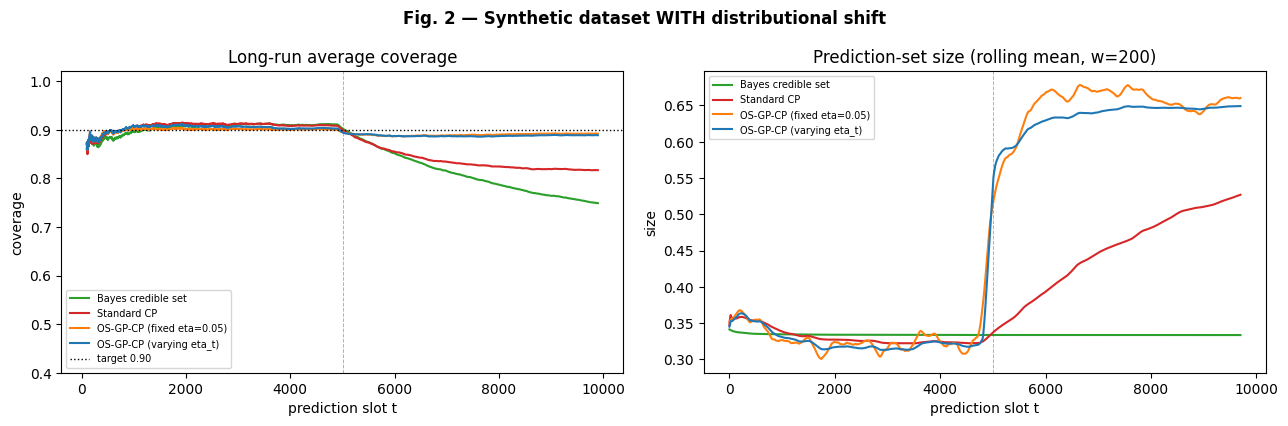

In [14]:
# --- dataset from data.ipynb (cell: "Shift data") ---
np.random.seed(42)
X_shift = np.random.rand(10000, 1) * 10
y_first = np.sin(X_shift[:5000, 0]) + np.random.randn(5000) * 0.1
y_last  = np.sin(X_shift[5000:, 0]) + np.random.randn(5000) * 0.2
y_shift = np.concatenate([y_first, y_last])

res_shift = run_experiment(X_shift, y_shift)
print("Synthetic distributional shift:")
summarize(res_shift)
plot_results(res_shift, "Fig. 2 — Synthetic dataset WITH distributional shift")


# 10.3 Experiment 3

Downloaded AAPL: 899 trading days

Real AAPL stock prices:
  fitted hyper-params:  lengthscale=32.843  sigma_f=19.554  sigma_n=0.097
  method                        final coverage   mean size
  Bayes credible set                     0.782       0.389
  Standard CP                            0.798       0.404
  OS-GP-CP (fixed eta=0.05)              0.839       0.450
  OS-GP-CP (varying eta_t)               0.806       0.407
  change-points detected (varying eta_t): []


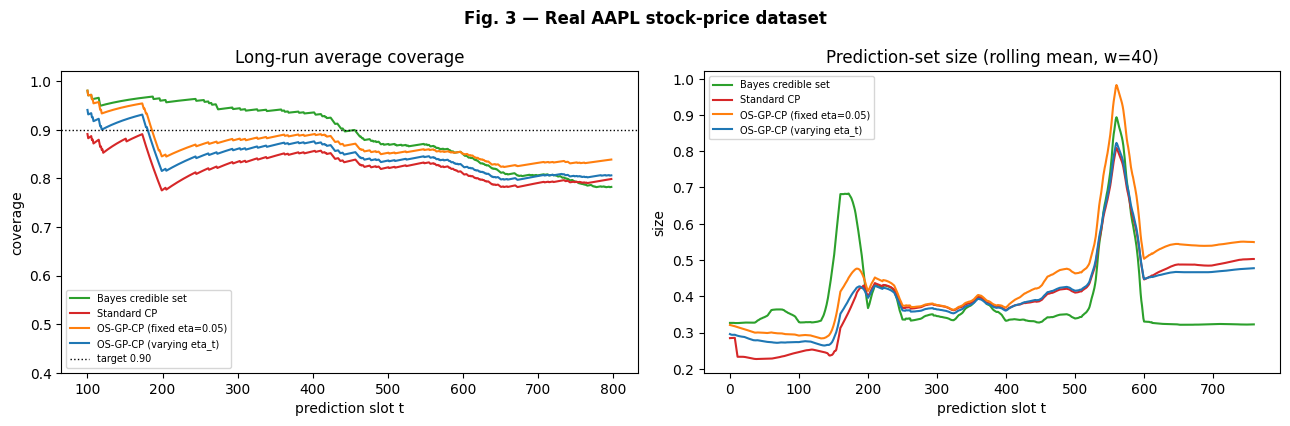

In [15]:
import warnings; warnings.filterwarnings("ignore")

def load_aapl(start="2016-01-04", end="2019-07-31"):
    import yfinance as yf
    data = yf.download("AAPL", start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(data.columns, __import__("pandas").MultiIndex):
        data.columns = data.columns.get_level_values(0)
    X = data[["Open", "High", "Low"]].to_numpy(float)
    y = data["Close"].to_numpy(float).ravel()
    return X, y

try:
    X_aapl, y_aapl = load_aapl()
    print(f"Downloaded AAPL: {len(y_aapl)} trading days")
except Exception as e:
    print("yfinance download failed (", type(e).__name__, ") -> using a drift surrogate.")
    rng = np.random.RandomState(0); T = 900
    level = np.cumsum(rng.randn(T) * 0.6) + 30
    X_aapl = np.c_[level + rng.randn(T) * 0.15, # window size, W = 15
                   level + np.abs(rng.randn(T)) * 0.25,
                   level - np.abs(rng.randn(T)) * 0.25]
    y_aapl = level + rng.randn(T) * 0.2

# fewer points than the synthetic sets -> smaller detector window / cooldown
res_aapl = run_experiment(X_aapl, y_aapl, n_init=100, standardize=True,
                          varying_kwargs=dict(W=50, cooldown=100))
print("\nReal AAPL stock prices:")
summarize(res_aapl)
plot_results(res_aapl, "Fig. 3 — Real AAPL stock-price dataset", size_window=40)
